In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu, ttest_ind, f_oneway
from scipy.stats import gaussian_kde
import os

In [2]:
# def read_trackmate_spots_csv(file_path):
#     """Reads the spots from a TrackMate CSV file and returns their intensities."""
#     df = pd.read_csv(file_path)
#     intensities = df.iloc[:, -1].tolist()  # Assuming the last column is the intensity
#     return intensities'''

In [3]:
def read_and_combine_intensities(directory_path):
    """Reads and combines the spots from multiple TrackMate CSV files for a single day."""
    # List all files in the directory that end with 'spots.csv'
    files = [file for file in os.listdir(directory_path) if file.endswith('spots.csv')]

    # Loop through the files and read each one
    combined_intensities = []
    for file_name in files:
        file_path = os.path.join(directory_path, file_name)
        with open(file_path, 'r') as file:
            # Read the contents of the file
            df = pd.read_csv(file_path)
            intensities = df.iloc[:, -1].tolist()
            combined_intensities.extend(intensities)
    return combined_intensities
    

In [4]:
def plot_intensity_distribution(intensities, titile):
    """Plots the distribution of spot intensities."""
    plt.hist(intensities, bins=50)
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.title(titile)
    plt.show()

In [5]:
def plot_intensity_histogram_and_pdf(intensities, ax, label):
    """Plots the histogram and PDF of intensities on the given axis."""
    ax.hist(intensities, bins=50, alpha=0.5, density=True, label=f'{label} Histogram')
    kde = gaussian_kde(intensities)
    x_range = np.linspace(min(intensities), max(intensities), 1000)
    ax.plot(x_range, kde(x_range), label=f'{label} PDF')

In [6]:
def plot_ecdf(data, ax, label):
    """Plots the empirical cumulative distribution function (ECDF) of the data."""
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.step(sorted_data, ecdf, where='post', label=label)
    #plt.xlabel('Intensity')
    #plt.ylabel('ECDF')
    #plt.title('Empirical Cumulative Distribution Function of Spot Intensities')
    #plt.legend()
    #plt.grid(True)
    #plt.show()

In [7]:
def compare_distributions(intensities_day1, intensities_day2):
    """Compares the distributions of spot intensities using the Kolmogorov-Smirnov test.
    The K-S statistic is then the maximum absolute difference between these two ECDFs across all intensity values."""
    " this is sensitive to shape and location of the cumulative distribution functions of the two samples"
    statistic, p_value = ks_2samp(intensities_day1, intensities_day2)
    print(f'Kolmogorov-Smirnov test statistic: {statistic}')
    print(f'P-value: {p_value}')
    if p_value < 0.05:
        print('The distributions are significantly different.')
    else:
        print('The distributions are not significantly different.')


In [8]:
def plot_intensity_histogram_and_pdf_separate(intensities, ax, label):
    """Plots the histogram and PDF of intensities overlaid on the same axis."""
    ax.hist(intensities, bins=50, alpha=0.5, density=True, label=f'{label} Histogram')
    kde = gaussian_kde(intensities)
    x_range = np.linspace(min(intensities), max(intensities), 1000)
    ax.plot(x_range, kde(x_range), label=f'{label} PDF')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Probability Density')
    ax.legend()

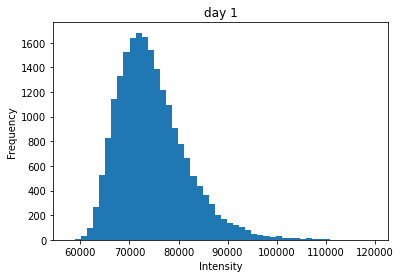

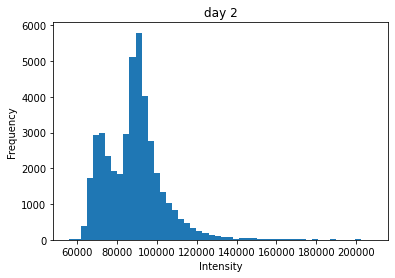

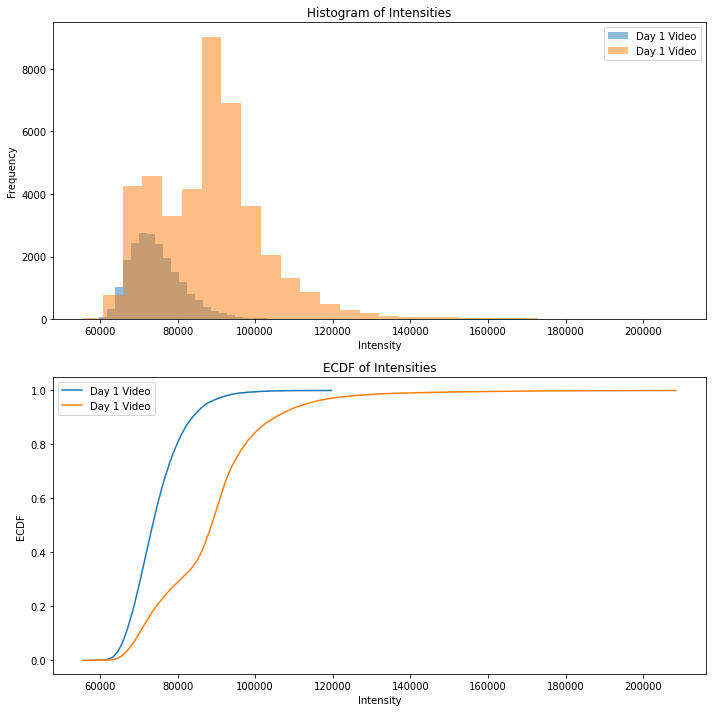

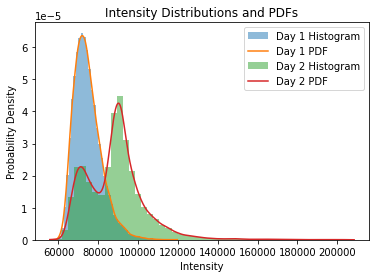

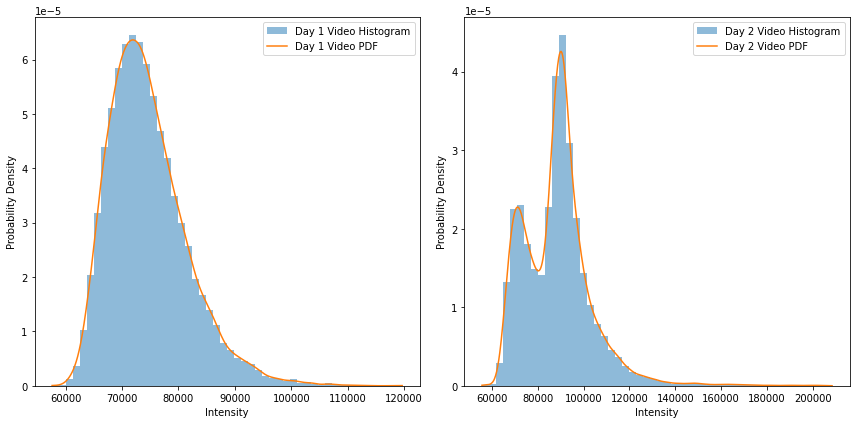

Kolmogorov-Smirnov test statistic: 0.5555327873307931
P-value: 0.0
The distributions are significantly different.
Mann-Whitney U Test: U-statistic=174159304.0, P-value=0.0
t-Test: t-statistic=-159.33172962893013, P-value=0.0
F-Test: F-statistic=16347.16544312775, P-value=0.0


In [11]:
def main():
    # Specify the directory containing the files day 1
    directory_path_1 = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/Rfa1_long_549_500msInt_5%_Sep1_HU_0.2_whole_batch'
    directory_path_2 = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/Rfa1_long_549_5%_Aug11_HU'
    
    intensities = read_and_combine_intensities(directory_path_1)
    intensities_2 = read_and_combine_intensities(directory_path_2)
    
    plot_intensity_distribution(intensities, 'day 1')
    plot_intensity_distribution(intensities_2,'day 2')
    #plot_ecdf(intensities, 'Intensity ECDF')
    #plot_ecdf(intensities_2, 'Intensity 2 ECDF')
    
    # Create a figure with subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    # Plot histograms
    axs[0].hist(intensities, bins=30, alpha=0.5, label='Day 1 Video')
    axs[0].hist(intensities_2, bins=30, alpha=0.5, label='Day 1 Video')
    axs[0].set_title('Histogram of Intensities')
    axs[0].set_xlabel('Intensity')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    # Plot ECDFs
    plot_ecdf(intensities, axs[1], 'Day 1 Video')
    plot_ecdf(intensities_2, axs[1], 'Day 1 Video')
    axs[1].set_title('ECDF of Intensities')
    axs[1].set_xlabel('Intensity')
    axs[1].set_ylabel('ECDF')
    axs[1].legend()
    # Show the plots
    plt.tight_layout()
    plt.show()

    
    fig, ax = plt.subplots()
    plot_intensity_histogram_and_pdf(intensities, ax, 'Day 1')
    plot_intensity_histogram_and_pdf(intensities_2, ax, 'Day 2')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Probability Density')
    ax.set_title('Intensity Distributions and PDFs')
    ax.legend()
    plt.show()
    
    
    # Plotting the results separately
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plot_intensity_histogram_and_pdf_separate(intensities, axs[0], 'Day 1 Video')
    plot_intensity_histogram_and_pdf_separate(intensities_2, axs[1], 'Day 2 Video')
    plt.tight_layout()
    plt.show()

    compare_distributions(intensities, intensities_2)
    # Mann-Whitney U Test - Use this for non-parametric data
    u_stat, u_p_value = mannwhitneyu(intensities, intensities_2)

    # t-Test - Use this if you're sure the data follows a normal distribution
    t_stat, t_p_value = ttest_ind(intensities, intensities_2, equal_var=False)

    # F-Test - This test compares the variances of the two groups
    f_stat, f_p_value = f_oneway(intensities, intensities_2)
    print(f"Mann-Whitney U Test: U-statistic={u_stat}, P-value={u_p_value}")
    print(f"t-Test: t-statistic={t_stat}, P-value={t_p_value}")
    print(f"F-Test: F-statistic={f_stat}, P-value={f_p_value}")

if __name__ == '__main__':
    main()

In [10]:
quality
other intensity features
for all of the videos
normalization? backgraound 
pdf

SyntaxError: invalid syntax (621441896.py, line 2)